In [2]:
from IPython.display import display, HTML
display(HTML("""
<style>
div.container{width:90% !important;}
div.cell.code_cell.rendered{width:100%;}
div.input_prompt{padding:0px;}
div.CodeMirror {font-family:Consolas; font-size:20pt;}
.inner_cell{font-size:20pt;}
div.text_cell_render pre code {font-size:20pt; line-height:30px;}
div.output {font-size:20pt; font-weight:bold;}
div.input {font-family:Consolas; font-size:20pt;}
div.prompt {min-width:70px;}
div#toc-wrapper{padding-top:120px;}
div.text_cell_render ul li{font-size:20pt;padding:5px;}
table.dataframe{font-size:20px;}
</style>
"""))

<font size="6" color="red">ch11.데이터프레임과 시리즈(Pandas)_9절~14절</font>
# 9절. 데이터 그룹화 및 집계

In [5]:
from statsmodels.api import datasets 
iris=datasets.get_rdataset('iris').data
iris.iloc[[0,49,50,99,100,149]]

,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width,Species
0,5.1,3.5,1.4,0.2,setosa
49,5.0,3.3,1.4,0.2,setosa
50,7.0,3.2,4.7,1.4,versicolor
99,5.7,2.8,4.1,1.3,versicolor
100,6.3,3.3,6.0,2.5,virginica
149,5.9,3.0,5.1,1.8,virginica


## 9.1Group by 
    cf. pivot_table 

In [7]:
iris.groupby('Species')[['Sepal.Length','Sepal.Width']].sum()

,Sepal.Length,Sepal.Width
Species,,
setosa,250.3,171.4
versicolor,296.8,138.5
virginica,329.4,148.7


In [38]:
# 1) 그룹화 방법 1
# df.groupby(by =[그룹핑 할 열이름 ])[함수적용해서 출력할열들].기초통계함수()
    #[함수적용해서 출력할열들] 생략시 모든 열이 적용 
    
iris_grouped = iris.groupby('Species')
iris.grouped = iris.groupby(iris.Species)
iris_grouped_sum = iris_grouped.sum()
iris_grouped_sum  # iris.groupby('Species').sum()


,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width
Species,,,,
setosa,250.3,171.4,73.1,12.3
versicolor,296.8,138.5,213.0,66.3
virginica,329.4,148.7,277.6,101.3


In [39]:
#setosa, virginica의 집계만 
iris_grouped_sum.loc[['setosa','virginica']]

,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width
Species,,,,
setosa,250.3,171.4,73.1,12.3
virginica,329.4,148.7,277.6,101.3


In [14]:
print(iris_grouped_sum.index)

Index(['setosa', 'versicolor', 'virginica'], dtype='object', name='Species')


In [40]:
iris_grouped_sum.reset_index(inplace=True)# 인덱스를 컬럼으로 편입시킨것 

In [41]:
iris_grouped_sum

,Species,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width
0,setosa,250.3,171.4,73.1,12.3
1,versicolor,296.8,138.5,213.0,66.3
2,virginica,329.4,148.7,277.6,101.3


In [18]:
# setosa, virginica의 집계만  
iris_grouped_sum[(iris_grouped_sum.Species=='setosa') | (iris_grouped_sum.Species=='virginica')]
iris_grouped_sum[iris_grouped_sum.Species.isin(['setosa', 'virginica'])]

,Species,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width
0,setosa,250.3,171.4,73.1,12.3
2,virginica,329.4,148.7,277.6,101.3


In [19]:
# 1) 그룹화 방법 1-1 :그룹핑 할때 index를 컬럼데이터로 편입 (reset_index()가 필요X)
# df.groupby(by =[그룹핑 할 열이름 ], as_index=False)[함수적용해서 출력할열들].기초통계함수()
    #[함수적용해서 출력할열들] 생략시 모든 열이 적용 
    
iris.groupby(iris['Species'], as_index=False).sum()  
iris.groupby(iris.Species, as_index=False).sum()  
iris.groupby('Species', as_index=False).sum()


,Species,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width
0,setosa,250.3,171.4,73.1,12.3
1,versicolor,296.8,138.5,213.0,66.3
2,virginica,329.4,148.7,277.6,101.3


In [24]:
#종별 Sepal.Length 와 Sepal.Width의 평균
iris.groupby('Species').mean()[['Sepal.Length','Sepal.Width']]
iris.groupby('Species')[['Sepal.Length','Sepal.Width']].mean()

,Sepal.Length,Sepal.Width
Species,,
setosa,5.006,3.428
versicolor,5.936,2.770
virginica,6.588,2.974


In [27]:
# 종별 Sepal.Length의 합계 
iris.groupby('Species')[['Sepal.Length']].sum() # 결과 시리즈 (1차원)

,Sepal.Length
Species,
setosa,250.3
versicolor,296.8
virginica,329.4


In [45]:
#그룹화 방법1
# df.groupby(by=[그룹핑할 열이름들], as_index=T/F)[함수적용해서 출력할열들].함수명()
#그룹화 방법2
#df.pivot_table(index='그룹핑할 열이름'
#               values= ['함수적용해서출력할 열들'],
#               aggfunc=함수명(기본값:mean)
#               )
iris.groupby('Species').mean()
g= iris.pivot_table(index='Species', 
                #values=
                #aggfunc='mean'
                )
g

,Petal.Length,Petal.Width,Sepal.Length,Sepal.Width
Species,,,,
setosa,1.462,0.246,5.006,3.428
versicolor,4.260,1.326,5.936,2.770
virginica,5.552,2.026,6.588,2.974


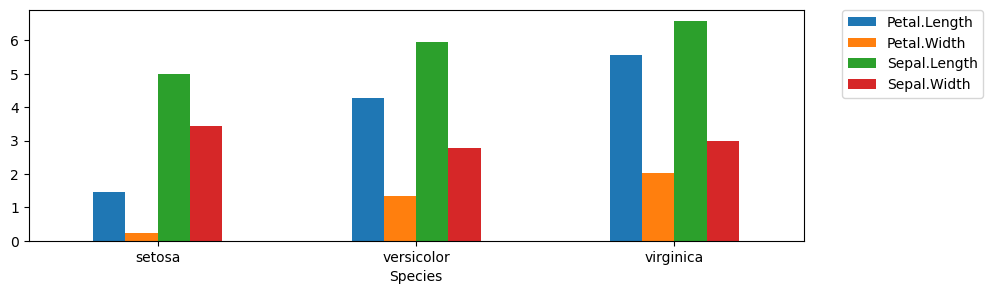

In [57]:
#범례를 밖으로: 시각화 20page. 판다스 60page. 
import matplotlib.pyplot as plt
g.plot(kind='bar', figsize=(10,3), rot=0)
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.) #범례를 밖으로 빠지게 하는 방법 
plt.show()

In [64]:
iris.pivot_table(index='Species', 
                 values='Sepal.Length', 
                 aggfunc='count'      )
iris.groupby('Species')['Sepal.Length'].count()
iris['Species'].value_counts() #정렬까지

setosa        50
versicolor    50
virginica     50
Name: Species, dtype: int64

In [83]:


#임의로 각 열마다 결측치를 할당 (0번째 열은 결측치 1/1번째 열은 결측치 2/ 2번째 열은 결측치 3/ 3번째 열은 결측치 4)
import numpy as np
import random 
#random.sample(range(0, 150), 2)
for col in range(iris.shape[1]-1):
    rows = random.sample(range(len(iris)), col+1)
   # iris.iloc[rows, col]= np.nan


In [85]:

iris.isna().sum()

Sepal.Length    1
Sepal.Width     2
Petal.Length    3
Petal.Width     4
Species         0
dtype: int64

In [88]:
# 열별 결측치를 제외한 데이터 갯수 
iris.groupby('Species').count() 
iris.pivot_table(index='Species', aggfunc='count')

,Petal.Length,Petal.Width,Sepal.Length,Sepal.Width
Species,,,,
setosa,49,50,50,49
versicolor,49,46,50,49
virginica,49,50,49,50


In [89]:
iris

,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width,Species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


### 다중열로 그룹화 

In [91]:
iris.head(1)

,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width,Species
0,5.1,3.5,1.4,0.2,setosa


In [97]:
# iris 로 다중열 그룹화 하기 위해 데이터 추가 (num컬럼)
# iris 행수는 150개 = Species 3그룹 , num 6그룹 
#np.array([[i]*25 for i in range(6)]).ravel()
iris['num'] = np.array([[i]*25 for i in range(6)]).flatten()
iris.iloc[::25]

,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width,Species,num
0,5.1,3.5,1.4,0.2,setosa,0
25,5.0,3.0,1.6,0.2,setosa,1
50,7.0,3.2,4.7,1.4,versicolor,2
75,6.6,3.0,4.4,1.4,versicolor,3
100,6.3,3.3,6.0,2.5,virginica,4
125,7.2,3.2,6.0,1.8,virginica,5


In [100]:
# 종별, num별로 합계
r=iris.groupby(['Species', 'num']).sum()


Sepal.Length  Sepal.Width  Petal.Length  Petal.Width
Species    num                                                      
setosa     0           125.7         83.4          35.0          6.2
           1           124.6         84.4          36.6          6.1
versicolor 2           150.3         69.4         107.8         30.5
           3           146.5         66.7         100.2         30.7
virginica  4           158.6         73.2         141.0         51.1
           5           165.0         75.5         131.5         50.2

In [101]:
r.index

MultiIndex([(    'setosa', 0),
            (    'setosa', 1),
            ('versicolor', 2),
            ('versicolor', 3),
            ( 'virginica', 4),
            ( 'virginica', 5)],
           names=['Species', 'num'])

In [102]:
r.loc[['setosa', 'virginica']] #setosa와 virginica의 합 계만 

Sepal.Length  Sepal.Width  Petal.Length  Petal.Width
Species   num                                                      
setosa    0           125.7         83.4          35.0          6.2
          1           124.6         84.4          36.6          6.1
virginica 4           158.6         73.2         141.0         51.1
          5           165.0         75.5         131.5         50.2

In [103]:
r.loc[[('setosa', 0), ('virginica', 5)]]

,,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width
Species,num,,,,
setosa,0,125.7,83.4,35.0,6.2
virginica,5,165.0,75.5,131.5,50.2


In [105]:
# 종별, num별로 합계
iris.pivot_table(index=['Species','num'])

Petal.Length  Petal.Width  Sepal.Length  Sepal.Width
Species    num                                                      
setosa     0        1.458333     0.248000      5.028000     3.475000
           1        1.464000     0.244000      4.984000     3.376000
versicolor 2        4.312000     1.326087      6.012000     2.776000
           3        4.175000     1.334783      5.860000     2.779167
virginica  4        5.640000     2.044000      6.608333     2.928000
           5        5.479167     2.008000      6.600000     3.020000

In [106]:
#종별 기초 통계량들 
iris.groupby(['Species']).describe().T

Species                setosa  versicolor  virginica
Sepal.Length count  50.000000   50.000000  49.000000
             mean    5.006000    5.936000   6.604082
             std     0.352490    0.516171   0.632113
             min     4.300000    4.900000   4.900000
             25%     4.800000    5.600000   6.300000
             50%     5.000000    5.900000   6.500000
             75%     5.200000    6.300000   6.900000
             max     5.800000    7.000000   7.900000
Sepal.Width  count  49.000000   49.000000  50.000000
             mean    3.424490    2.777551   2.974000
             std     0.382171    0.312427   0.322497
             min     2.300000    2.000000   2.200000
             25%     3.200000    2.600000   2.800000
             50%     3.400000    2.800000   3.000000
             75%     3.700000    3.000000   3.175000
             max     4.400000    3.400000   3.800000
Petal.Length count  49.000000   49.000000  49.000000
             mean    1.461224    4.244898   5.561224
             std     0.175376    0.462359   0.553706
             min     1.000000    3.000000   4.500000
             25%     1.400000    4.000000   5.100000
             50%     1.500000    4.300000   5.600000
             75%     1.600000    4.600000   5.900000
             max     1.900000    5.100000   6.900000
Petal.Width  count  50.000000   46.000000  50.000000
             mean    0.246000    1.330435   2.026000
             std     0.105386    0.188408   0.274650
             min     0.100000    1.000000   1.400000
             25%     0.200000    1.200000   1.800000
             50%     0.200000    1.300000   2.000000
             75%     0.300000    1.500000   2.300000
             max     0.600000    1.800000   2.500000
num          count  50.000000   50.000000  50.000000
             mean    0.500000    2.500000   4.500000
             std     0.505076    0.505076   0.505076
             min     0.000000    2.000000   4.000000
             25%     0.000000    2.000000   4.000000
             50%     0.500000    2.500000   4.500000
             75%     1.000000    3.000000   5.000000
             max     1.000000    3.000000   5.000000